# Chapter 38 — A Neuron as a Small Function

## Learning goals

Previous chapters trained affine models such as `prediction = weight × input + bias`.

This chapter packages the same idea into one artificial neuron with several inputs and an optional activation function.

By the end of this chapter, you should be able to:

1. Explain an artificial neuron as a mathematical function.
2. Identify inputs, weights, bias, weighted sum, activation, and output.
3. Implement one neuron with pure Python lists.
4. Explain the difference between a linear map and an affine map.
5. Define and plot ReLU.
6. Explain ReLU's forward and backward behavior.
7. Implement one neuron with homemade scalar autograd.
8. Train one neuron on several examples.
9. Draw several inputs flowing into one output.
10. Explain why stacked affine layers collapse into one affine layer.
11. Explain how nonlinear activations make depth more expressive.

## A neuron is a function

In this course, an artificial neuron is a small numerical function rather than a biological analogy.

It:

- Receives several input numbers.
- Multiplies each input by a corresponding weight.
- Sums the products and adds a bias.
- Optionally applies an activation function.
- Returns one output number.

For two inputs:

```python
weighted_sum = input_1 * weight_1 + input_2 * weight_2 + bias
output = activation(weighted_sum)
```

## Terms used in this chapter

- An **input** is one number given to the neuron.
- A **weight** is a learnable parameter paired with one input coordinate.
- A **bias** is a learnable parameter added after the weighted products are summed.
- A **weighted sum** or **pre-activation** is the input-weight sum plus bias.
- An **activation function** transforms the weighted sum.
- A **neuron output** is the value after the optional activation.
- **ReLU** is the activation `max(0, x)`.
- An **affine function** has the form `w · x + b`.
- A **layer** is a group of neurons that returns several outputs.

A function with weights but no bias is linear in the strict mathematical sense.

Adding a nonzero bias makes it affine, although machine-learning discussions often use “linear layer” for both.

## Compute one neuron by hand

Use two inputs, two weights, and one bias.

In [1]:
input_1 = 2.0
input_2 = 3.0
weight_1 = 0.5
weight_2 = -1.0
bias = 4.0

first_product = input_1 * weight_1
second_product = input_2 * weight_2
weighted_sum = first_product + second_product + bias

print("First product:", first_product)
print("Second product:", second_product)
print("Bias:", bias)
print("Weighted sum:", weighted_sum)

First product: 1.0
Second product: -3.0
Bias: 4.0
Weighted sum: 2.0


The calculation is `2 × 0.5 + 3 × -1 + 4 = 2`.

Without an activation, the neuron output equals this weighted sum.

## Inputs and parameters have different roles

The input values are data supplied for one example.

Weights and bias are persistent parameters changed by training.

Different examples reuse the same parameter values but provide different inputs.

## Use lists for any input dimension

A neuron needs exactly one weight per input coordinate.

Validate that invariant before computing.

In [2]:
def validate_neuron_inputs(
    input_values: list[float],
    weight_values: list[float],
) -> None:
    if len(input_values) != len(weight_values):
        raise ValueError("input_values and weight_values must have the same length.")

    if len(input_values) == 0:
        raise ValueError("A neuron must have at least one input.")


def compute_weighted_sum(
    input_values: list[float],
    weight_values: list[float],
    bias_value: float,
) -> float:
    validate_neuron_inputs(input_values, weight_values)
    weighted_sum = bias_value

    for input_value, weight_value in zip(
        input_values,
        weight_values,
        strict=True,
    ):
        weighted_sum += input_value * weight_value

    return weighted_sum

Run the same example through the reusable function.

In [3]:
input_values = [2.0, 3.0]
weight_values = [0.5, -1.0]
bias_value = 4.0

list_weighted_sum = compute_weighted_sum(
    input_values,
    weight_values,
    bias_value,
)

print("Input values:", input_values)
print("Weight values:", weight_values)
print("Bias value:", bias_value)
print("Weighted sum:", list_weighted_sum)

assert list_weighted_sum == 2.0

Input values: [2.0, 3.0]
Weight values: [0.5, -1.0]
Bias value: 4.0
Weighted sum: 2.0


This loop is a dot product followed by bias addition.

## Print every weighted contribution

The running total makes the neuron calculation explicit.

In [4]:
running_sum = bias_value

print("Start with bias:", running_sum)

for position, (input_value, weight_value) in enumerate(
    zip(input_values, weight_values, strict=True)
):
    product = input_value * weight_value
    running_sum += product
    print(
        f"position {position}: "
        f"{input_value} × {weight_value} = {product}; "
        f"running sum = {running_sum}"
    )

print("Final weighted sum:", running_sum)

Start with bias: 4.0
position 0: 2.0 × 0.5 = 1.0; running sum = 5.0
position 1: 3.0 × -1.0 = -3.0; running sum = 2.0
Final weighted sum: 2.0


Every input coordinate contributes through its paired weight, while bias contributes directly.

## Draw several inputs flowing to one output

The diagram separates input values, weighted connections, pre-activation, and optional activation.

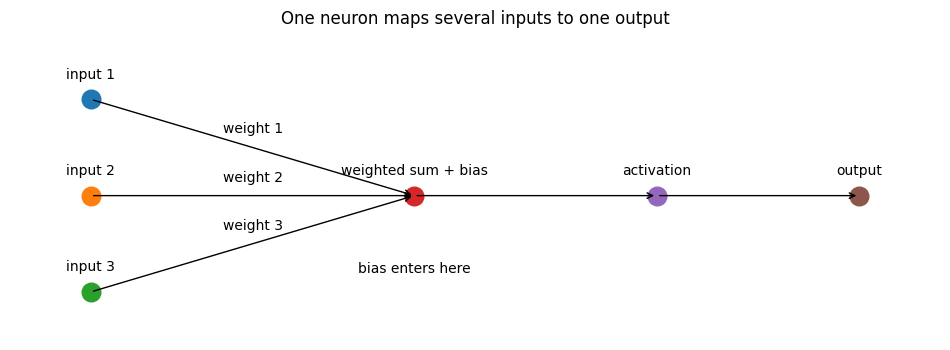

In [5]:
import matplotlib.pyplot as plt

node_positions = {
    "input 1": (0.0, 2.5),
    "input 2": (0.0, 1.5),
    "input 3": (0.0, 0.5),
    "weighted sum + bias": (4.0, 1.5),
    "activation": (7.0, 1.5),
    "output": (9.5, 1.5),
}
edges = [
    ("input 1", "weighted sum + bias", "weight 1"),
    ("input 2", "weighted sum + bias", "weight 2"),
    ("input 3", "weighted sum + bias", "weight 3"),
    ("weighted sum + bias", "activation", ""),
    ("activation", "output", ""),
]

plt.figure(figsize=(12, 4))

for start_node, end_node, edge_label in edges:
    start_x, start_y = node_positions[start_node]
    end_x, end_y = node_positions[end_node]
    plt.annotate(
        "",
        xy=(end_x, end_y),
        xytext=(start_x, start_y),
        arrowprops={"arrowstyle": "->", "color": "black"},
    )

    if edge_label:
        plt.text(
            (start_x + end_x) / 2,
            (start_y + end_y) / 2 + 0.15,
            edge_label,
            ha="center",
        )

for node_name, (x_position, y_position) in node_positions.items():
    plt.scatter([x_position], [y_position], s=180)
    plt.text(x_position, y_position + 0.22, node_name, ha="center")

plt.text(4.0, 0.7, "bias enters here", ha="center")
plt.xlim(-1, 10.5)
plt.ylim(0, 3.2)
plt.axis("off")
plt.title("One neuron maps several inputs to one output")
plt.show()

The diagram describes dependencies, not a biological cell.

## Define ReLU

The rectified linear unit is:

```text
ReLU(x) = 0 when x ≤ 0
ReLU(x) = x when x > 0
```

It is continuous but has a corner at zero.

In [6]:
def relu(input_number: float) -> float:
    return input_number if input_number > 0 else 0.0


for test_input in [-3.0, -1.0, 0.0, 1.0, 3.0]:
    print(f"ReLU({test_input:>4.1f}) = {relu(test_input):.1f}")

ReLU(-3.0) = 0.0
ReLU(-1.0) = 0.0
ReLU( 0.0) = 0.0
ReLU( 1.0) = 1.0
ReLU( 3.0) = 3.0


ReLU preserves positive values and replaces nonpositive values with zero.

At exactly zero, the mathematical derivative is not uniquely defined; our later engine will use derivative zero by convention.

## Add an optional activation

Weighted sum and neuron output are different values whenever an activation is applied.

In [7]:
def compute_neuron_output(
    input_values: list[float],
    weight_values: list[float],
    bias_value: float,
    use_relu: bool,
) -> float:
    weighted_sum = compute_weighted_sum(
        input_values,
        weight_values,
        bias_value,
    )

    if use_relu:
        return relu(weighted_sum)

    return weighted_sum


positive_output = compute_neuron_output(
    [2.0, 3.0],
    [0.5, -1.0],
    4.0,
    use_relu=True,
)
negative_weighted_sum = compute_weighted_sum(
    [2.0, 3.0],
    [0.5, -1.0],
    0.0,
)
clipped_output = compute_neuron_output(
    [2.0, 3.0],
    [0.5, -1.0],
    0.0,
    use_relu=True,
)

print("Positive-case output:", positive_output)
print("Negative weighted sum:", negative_weighted_sum)
print("Output after ReLU:", clipped_output)

Positive-case output: 2.0
Negative weighted sum: -2.0
Output after ReLU: 0.0


The positive weighted sum passes through unchanged, while the negative weighted sum becomes zero.

## Plot ReLU and a stacked-function example

The first panel shows ReLU's corner.

The second compares stacked affine functions with and without an intervening ReLU.

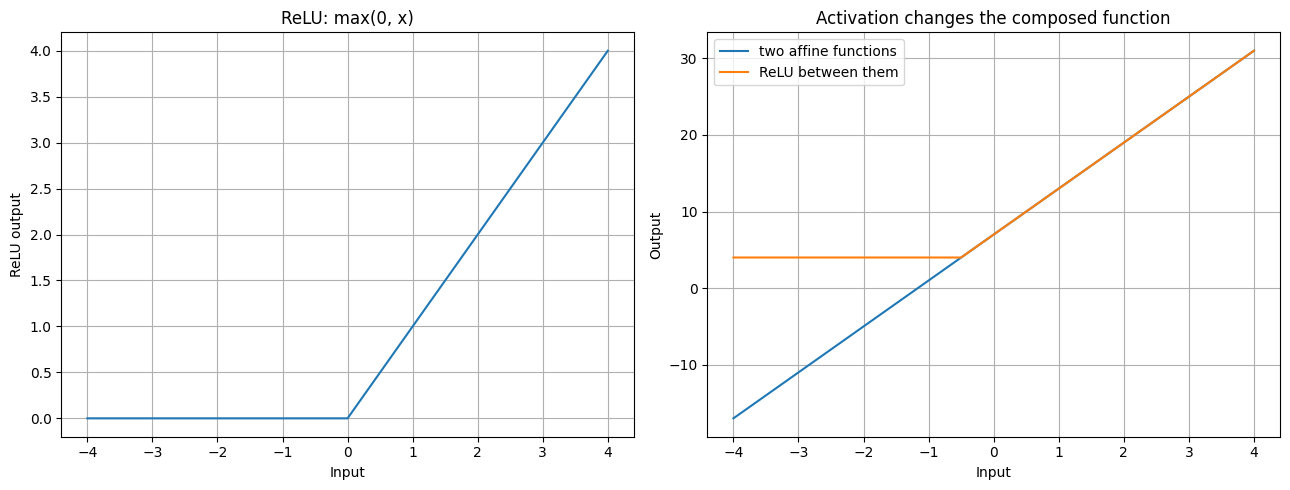

In [8]:
def first_affine(input_number: float) -> float:
    return 2 * input_number + 1


def second_affine(first_output: float) -> float:
    return 3 * first_output + 4


def collapsed_affine(input_number: float) -> float:
    return 6 * input_number + 7


def stacked_with_relu(input_number: float) -> float:
    return second_affine(relu(first_affine(input_number)))


x_values = [-4.0 + step * 0.1 for step in range(81)]
relu_values = [relu(x_value) for x_value in x_values]
collapsed_values = [collapsed_affine(x_value) for x_value in x_values]
nonlinear_stack_values = [stacked_with_relu(x_value) for x_value in x_values]

figure, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(x_values, relu_values)
axes[0].set_xlabel("Input")
axes[0].set_ylabel("ReLU output")
axes[0].set_title("ReLU: max(0, x)")
axes[0].grid(True)

axes[1].plot(
    x_values,
    collapsed_values,
    label="two affine functions",
)
axes[1].plot(
    x_values,
    nonlinear_stack_values,
    label="ReLU between them",
)
axes[1].set_xlabel("Input")
axes[1].set_ylabel("Output")
axes[1].set_title("Activation changes the composed function")
axes[1].legend()
axes[1].grid(True)

figure.tight_layout()
plt.show()

Composing `2x + 1` with `3x + 4` gives exactly `6x + 7`, another affine function.

Inserting ReLU creates a bend, so one affine function can no longer represent the result everywhere.

## Why nonlinearity matters for depth

Any finite composition of affine maps is another affine map.

Therefore, adding more affine-only layers increases parameterization but not the class of functions the stack can represent.

Nonlinear activations prevent that collapse and let deeper networks construct more complicated piecewise functions.

This does not mean every neuron must always use ReLU; output layers often use a different activation or no activation, depending on the task.

## Extend homemade autograd with ReLU

Use the PyTorch-like leaf accumulation policy from Chapter 37.

The ReLU backward rule captures whether its input was positive during the forward pass.

In [9]:
from collections.abc import Callable


class TrackedNumber:
    def __init__(
        self,
        data: float,
        previous_values: tuple["TrackedNumber", ...] = (),
        operation: str = "",
        label: str = "",
    ) -> None:
        self.data = float(data)
        self.gradient = 0.0
        self._previous_values = previous_values
        self._operation = operation
        self.label = label
        self._backward: Callable[[], None] = lambda: None

    def __repr__(self) -> str:
        return (
            f"TrackedNumber(data={self.data}, "
            f"gradient={self.gradient}, "
            f"label={self.label!r})"
        )

    @staticmethod
    def _ensure_tracked(value: object) -> "TrackedNumber":
        if isinstance(value, TrackedNumber):
            return value

        if isinstance(value, int | float):
            return TrackedNumber(float(value))

        raise TypeError(
            f"Expected a TrackedNumber, int, or float. Received {type(value).__name__}."
        )

    def __add__(self, other: object) -> "TrackedNumber":
        other_value = self._ensure_tracked(other)
        output = TrackedNumber(
            self.data + other_value.data,
            previous_values=(self, other_value),
            operation="+",
        )

        def _backward() -> None:
            self.gradient += output.gradient
            other_value.gradient += output.gradient

        output._backward = _backward
        return output

    def __radd__(self, other: object) -> "TrackedNumber":
        return self + other

    def __sub__(self, other: object) -> "TrackedNumber":
        other_value = self._ensure_tracked(other)
        output = TrackedNumber(
            self.data - other_value.data,
            previous_values=(self, other_value),
            operation="-",
        )

        def _backward() -> None:
            self.gradient += output.gradient
            other_value.gradient -= output.gradient

        output._backward = _backward
        return output

    def __rsub__(self, other: object) -> "TrackedNumber":
        return self._ensure_tracked(other) - self

    def __mul__(self, other: object) -> "TrackedNumber":
        other_value = self._ensure_tracked(other)
        left_data = self.data
        right_data = other_value.data
        output = TrackedNumber(
            left_data * right_data,
            previous_values=(self, other_value),
            operation="*",
        )

        def _backward() -> None:
            self.gradient += right_data * output.gradient
            other_value.gradient += left_data * output.gradient

        output._backward = _backward
        return output

    def __rmul__(self, other: object) -> "TrackedNumber":
        return self * other

    def __truediv__(self, other: object) -> "TrackedNumber":
        other_value = self._ensure_tracked(other)
        numerator_data = self.data
        denominator_data = other_value.data

        if denominator_data == 0:
            raise ZeroDivisionError("Cannot divide by zero.")

        output = TrackedNumber(
            numerator_data / denominator_data,
            previous_values=(self, other_value),
            operation="/",
        )

        def _backward() -> None:
            self.gradient += output.gradient / denominator_data
            other_value.gradient -= (
                numerator_data * output.gradient / denominator_data**2
            )

        output._backward = _backward
        return output

    def __rtruediv__(self, other: object) -> "TrackedNumber":
        return self._ensure_tracked(other) / self

    def __pow__(self, exponent: int | float) -> "TrackedNumber":
        base_data = self.data
        output_data = base_data**exponent

        if isinstance(output_data, complex):
            raise ValueError("This engine supports real-valued powers only.")

        output = TrackedNumber(
            output_data,
            previous_values=(self,),
            operation=f"**{exponent}",
        )

        def _backward() -> None:
            self.gradient += exponent * base_data ** (exponent - 1) * output.gradient

        output._backward = _backward
        return output

    def relu(self) -> "TrackedNumber":
        was_positive = self.data > 0
        output = TrackedNumber(
            self.data if was_positive else 0.0,
            previous_values=(self,),
            operation="relu",
        )

        def _backward() -> None:
            local_derivative = 1.0 if was_positive else 0.0
            self.gradient += local_derivative * output.gradient

        output._backward = _backward
        return output

    def _topological_order(self) -> list["TrackedNumber"]:
        ordered_values = []
        visited_values = set()

        def visit(current_value: "TrackedNumber") -> None:
            if current_value in visited_values:
                return

            visited_values.add(current_value)

            for previous_value in current_value._previous_values:
                visit(previous_value)

            ordered_values.append(current_value)

        visit(self)
        return ordered_values

    def backward(self) -> None:
        ordered_values = self._topological_order()

        for value in ordered_values:
            if value._previous_values:
                value.gradient = 0.0

        self.gradient = 1.0

        for value in reversed(ordered_values):
            value._backward()

The captured `was_positive` flag ensures the backward rule matches the forward branch.

## Check ReLU gradients

Positive inputs pass gradient one, negative inputs pass zero, and this engine chooses zero at the corner.

In [10]:
relu_test_cases = [
    (3.0, 3.0, 1.0),
    (-3.0, 0.0, 0.0),
    (0.0, 0.0, 0.0),
]

for input_data, expected_output, expected_gradient in relu_test_cases:
    tracked_input = TrackedNumber(input_data)
    tracked_output = tracked_input.relu()
    tracked_output.backward()

    print(
        f"input={input_data:>4.1f}, "
        f"output={tracked_output.data:.1f}, "
        f"gradient={tracked_input.gradient:.1f}"
    )

    assert tracked_output.data == expected_output
    assert tracked_input.gradient == expected_gradient

input= 3.0, output=3.0, gradient=1.0
input=-3.0, output=0.0, gradient=0.0
input= 0.0, output=0.0, gradient=0.0


The zero convention is a practical implementation choice at ReLU's nondifferentiable corner.

## Implement a tracked neuron

One function computes the weighted sum and optionally applies ReLU.

In [11]:
def validate_tracked_neuron_inputs(
    input_values: list[float],
    weight_values: list[TrackedNumber],
) -> None:
    if len(input_values) != len(weight_values):
        raise ValueError("input_values and weight_values must have the same length.")

    if len(input_values) == 0:
        raise ValueError("A neuron must have at least one input.")


def tracked_neuron(
    input_values: list[float],
    weight_values: list[TrackedNumber],
    bias_value: TrackedNumber,
    use_relu: bool,
) -> TrackedNumber:
    validate_tracked_neuron_inputs(input_values, weight_values)
    weighted_sum = bias_value

    for input_value, weight_value in zip(
        input_values,
        weight_values,
        strict=True,
    ):
        weighted_sum = weighted_sum + input_value * weight_value

    if use_relu:
        return weighted_sum.relu()

    return weighted_sum

Without ReLU, the output gradient with respect to each weight equals its paired input and the bias gradient equals one.

In [12]:
tracked_weights = [
    TrackedNumber(0.5, label="weight_1"),
    TrackedNumber(-1.0, label="weight_2"),
]
tracked_bias = TrackedNumber(4.0, label="bias")
tracked_output = tracked_neuron(
    [2.0, 3.0],
    tracked_weights,
    tracked_bias,
    use_relu=False,
)
tracked_output.backward()

print("Neuron output:", tracked_output.data)
print("Weight gradients:", [value.gradient for value in tracked_weights])
print("Bias gradient:", tracked_bias.gradient)

assert tracked_output.data == 2.0
assert tracked_weights[0].gradient == 2.0
assert tracked_weights[1].gradient == 3.0
assert tracked_bias.gradient == 1.0

Neuron output: 2.0
Weight gradients: [2.0, 3.0]
Bias gradient: 1.0


Homemade autograd discovers these derivatives from the recorded scalar operations.

## ReLU can block the entire neuron gradient

Compare an active positive pre-activation with an inactive negative one.

In [13]:
active_weights = [
    TrackedNumber(0.5, label="active_weight_1"),
    TrackedNumber(-1.0, label="active_weight_2"),
]
active_bias = TrackedNumber(4.0, label="active_bias")
active_output = tracked_neuron(
    [2.0, 3.0],
    active_weights,
    active_bias,
    use_relu=True,
)
active_output.backward()

inactive_weights = [
    TrackedNumber(0.5, label="inactive_weight_1"),
    TrackedNumber(-1.0, label="inactive_weight_2"),
]
inactive_bias = TrackedNumber(0.0, label="inactive_bias")
inactive_output = tracked_neuron(
    [2.0, 3.0],
    inactive_weights,
    inactive_bias,
    use_relu=True,
)
inactive_output.backward()

print("Active output:", active_output.data)
print("Active weight gradients:", [value.gradient for value in active_weights])
print("Active bias gradient:", active_bias.gradient)
print()
print("Inactive output:", inactive_output.data)
print(
    "Inactive weight gradients:",
    [value.gradient for value in inactive_weights],
)
print("Inactive bias gradient:", inactive_bias.gradient)

Active output: 2.0
Active weight gradients: [2.0, 3.0]
Active bias gradient: 1.0

Inactive output: 0.0
Inactive weight gradients: [0.0, 0.0]
Inactive bias gradient: 0.0


When the pre-activation is negative, this ReLU sends zero gradient to every parameter feeding that output.

This behavior is sometimes called an inactive or “dead” ReLU and is one reason initialization matters.

## Train one neuron on several examples

Use examples generated by `target = 3 × first_input + 4 × second_input`.

The desired mapping is affine, so train the neuron without ReLU.

Starting a ReLU neuron at exactly zero would use our zero-derivative convention and could prevent any learning.

In [14]:
training_inputs = [
    [1.0, 0.0],
    [0.0, 1.0],
    [1.0, 1.0],
    [2.0, 1.0],
]
training_targets = [3.0, 4.0, 7.0, 10.0]


def validate_training_dataset(
    training_inputs: list[list[float]],
    training_targets: list[float],
) -> None:
    if len(training_inputs) != len(training_targets):
        raise ValueError(
            "training_inputs and training_targets must have the same length."
        )

    if len(training_inputs) == 0:
        raise ValueError("The training dataset must not be empty.")


def average_neuron_loss(
    training_inputs: list[list[float]],
    training_targets: list[float],
    weight_values: list[TrackedNumber],
    bias_value: TrackedNumber,
) -> TrackedNumber:
    validate_training_dataset(training_inputs, training_targets)
    total_loss = TrackedNumber(0.0)

    for input_values, target_value in zip(
        training_inputs,
        training_targets,
        strict=True,
    ):
        neuron_output = tracked_neuron(
            input_values,
            weight_values,
            bias_value,
            use_relu=False,
        )
        total_loss = total_loss + (neuron_output - target_value) ** 2

    return total_loss / len(training_inputs)


def clear_gradients(parameters: list[TrackedNumber]) -> None:
    for parameter in parameters:
        parameter.gradient = 0.0

Run full-batch gradient descent and store only plain scalar history.

In [15]:
def train_one_neuron(
    training_inputs: list[list[float]],
    training_targets: list[float],
    learning_rate: float,
    number_of_steps: int,
) -> tuple[
    list[dict[str, float]],
    list[TrackedNumber],
    TrackedNumber,
]:
    if learning_rate <= 0:
        raise ValueError("learning_rate must be positive.")

    if number_of_steps < 1:
        raise ValueError("number_of_steps must be at least 1.")

    number_of_inputs = len(training_inputs[0])
    weight_values = [
        TrackedNumber(0.0, label=f"weight_{index}") for index in range(number_of_inputs)
    ]
    bias_value = TrackedNumber(0.0, label="bias")
    parameters = weight_values + [bias_value]
    history = []

    for step in range(number_of_steps):
        average_loss = average_neuron_loss(
            training_inputs,
            training_targets,
            weight_values,
            bias_value,
        )
        clear_gradients(parameters)
        average_loss.backward()

        history.append(
            {
                "step": step,
                "loss": average_loss.data,
                "weight_1": weight_values[0].data,
                "weight_2": weight_values[1].data,
                "bias": bias_value.data,
                "weight_1_gradient": weight_values[0].gradient,
                "weight_2_gradient": weight_values[1].gradient,
                "bias_gradient": bias_value.gradient,
            }
        )

        for parameter in parameters:
            parameter.data -= learning_rate * parameter.gradient

    return history, weight_values, bias_value

Print a short run before training longer.

In [16]:
short_history, short_weights, short_bias = train_one_neuron(
    training_inputs,
    training_targets,
    learning_rate=0.03,
    number_of_steps=12,
)

assert len(short_weights) == 2
assert isinstance(short_bias, TrackedNumber)

print("step | loss | weight 1 | weight 2 | bias | grad w1 | grad w2 | grad bias")
print("-" * 88)

for row in short_history:
    print(
        f"{int(row['step']):>4} | "
        f"{row['loss']:>9.5f} | "
        f"{row['weight_1']:>8.5f} | "
        f"{row['weight_2']:>8.5f} | "
        f"{row['bias']:>8.5f} | "
        f"{row['weight_1_gradient']:>8.5f} | "
        f"{row['weight_2_gradient']:>8.5f} | "
        f"{row['bias_gradient']:>9.5f}"
    )

step | loss | weight 1 | weight 2 | bias | grad w1 | grad w2 | grad bias
----------------------------------------------------------------------------------------
   0 |  43.50000 |  0.00000 |  0.00000 |  0.00000 | -15.00000 | -10.50000 | -12.00000
   1 |  30.33699 |  0.45000 |  0.31500 |  0.36000 | -12.45750 | -8.81250 |  -9.90750
   2 |  21.24526 |  0.82373 |  0.57937 |  0.65722 | -10.34531 | -7.40951 |  -8.16904
   3 |  14.96439 |  1.13408 |  0.80166 |  0.90230 | -8.59066 | -6.24294 |  -6.72475
   4 |  10.62421 |  1.39180 |  0.98895 |  1.10404 | -7.13309 | -5.27281 |  -5.52489
   5 |   7.62394 |  1.60580 |  1.14713 |  1.26979 | -5.92234 | -4.46593 |  -4.52814
   6 |   5.54880 |  1.78347 |  1.28111 |  1.40563 | -4.91667 | -3.79469 |  -3.70014
   7 |   4.11244 |  1.93097 |  1.39495 |  1.51663 | -4.08140 | -3.23617 |  -3.01237
   8 |   3.11713 |  2.05341 |  1.49204 |  1.60700 | -3.38771 | -2.77132 |  -2.44112
   9 |   2.42639 |  2.15504 |  1.57518 |  1.68024 | -2.81164 | -2.38432 |  -1.

The loss falls as the two weights and bias receive different gradients.

## Train to a close fit

Use 2,000 steps and verify the learned parameters and predictions.

In [17]:
neuron_history, learned_weights, learned_bias = train_one_neuron(
    training_inputs,
    training_targets,
    learning_rate=0.03,
    number_of_steps=2_000,
)

final_loss = average_neuron_loss(
    training_inputs,
    training_targets,
    learned_weights,
    learned_bias,
)
final_predictions = [
    tracked_neuron(
        input_values,
        learned_weights,
        learned_bias,
        use_relu=False,
    ).data
    for input_values in training_inputs
]

print("Learned weights:", [value.data for value in learned_weights])
print("Learned bias:", learned_bias.data)
print("Final predictions:", final_predictions)
print("Final average loss:", final_loss.data)

assert abs(learned_weights[0].data - 3.0) < 0.01
assert abs(learned_weights[1].data - 4.0) < 0.01
assert abs(learned_bias.data) < 0.02
assert final_loss.data < 1e-5

Learned weights: [2.999996698697325, 3.9999886408865097]
Learned bias: 1.3139846378577202e-05
Final predictions: [3.0000098385437037, 4.000001780732888, 6.9999984794302135, 9.99999517812754]
Final average loss: 3.1382634582473686e-11


The neuron learns weights near `3` and `4` with bias near zero.

## Plot neuron training

One figure shows the loss curve and every parameter trajectory.

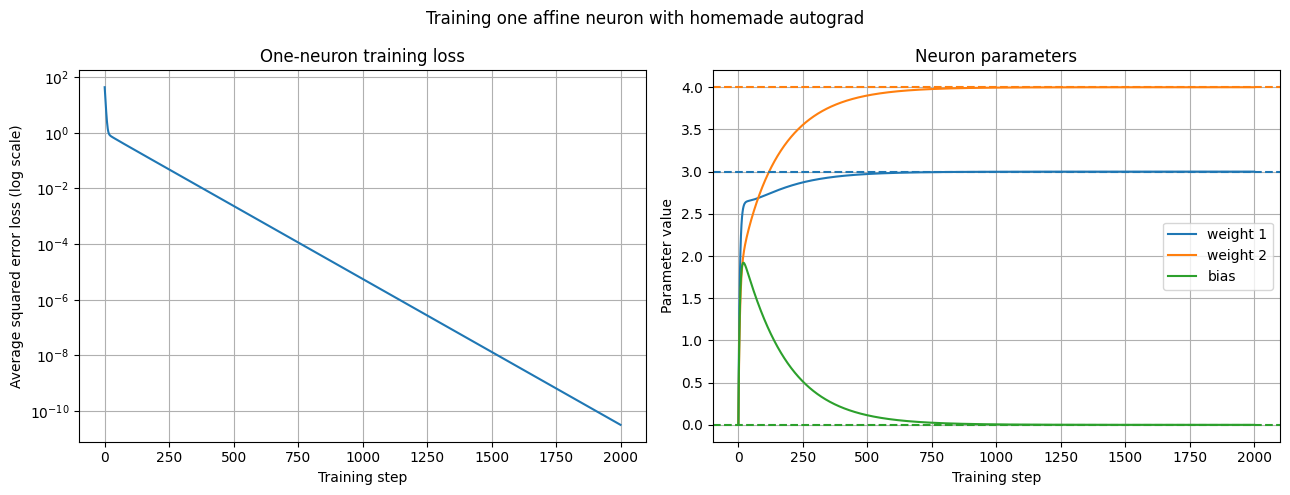

In [18]:
training_steps = [int(row["step"]) for row in neuron_history]
training_losses = [row["loss"] for row in neuron_history]
first_weights = [row["weight_1"] for row in neuron_history]
second_weights = [row["weight_2"] for row in neuron_history]
trained_biases = [row["bias"] for row in neuron_history]

figure, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(training_steps, training_losses)
axes[0].set_yscale("log")
axes[0].set_xlabel("Training step")
axes[0].set_ylabel("Average squared error loss (log scale)")
axes[0].set_title("One-neuron training loss")
axes[0].grid(True)

axes[1].plot(training_steps, first_weights, label="weight 1")
axes[1].plot(training_steps, second_weights, label="weight 2")
axes[1].plot(training_steps, trained_biases, label="bias")
axes[1].axhline(3.0, linestyle="--", color="tab:blue")
axes[1].axhline(4.0, linestyle="--", color="tab:orange")
axes[1].axhline(0.0, linestyle="--", color="tab:green")
axes[1].set_xlabel("Training step")
axes[1].set_ylabel("Parameter value")
axes[1].set_title("Neuron parameters")
axes[1].legend()
axes[1].grid(True)

figure.suptitle("Training one affine neuron with homemade autograd")
figure.tight_layout()
plt.show()

The same forward, clear, backward, and update loop now trains three neuron parameters.

## One neuron versus one layer

One neuron returns one scalar output.

A layer evaluates several neurons, each with its own weight vector and bias, and returns a vector of outputs.

The next chapter will package that repeated structure.

## A clean neuron pipeline

This final cell computes a ReLU neuron, a loss, and all parameter gradients.

In [19]:
pipeline_inputs = [2.0, 3.0]
pipeline_target = 5.0
pipeline_weights = [
    TrackedNumber(0.5, label="weight_1"),
    TrackedNumber(-1.0, label="weight_2"),
]
pipeline_bias = TrackedNumber(4.0, label="bias")
pipeline_parameters = pipeline_weights + [pipeline_bias]

pipeline_weighted_sum = tracked_neuron(
    pipeline_inputs,
    pipeline_weights,
    pipeline_bias,
    use_relu=False,
)
pipeline_output = pipeline_weighted_sum.relu()
pipeline_loss = (pipeline_output - pipeline_target) ** 2

clear_gradients(pipeline_parameters)
pipeline_loss.backward()

assert pipeline_weighted_sum.data == 2.0
assert pipeline_output.data == 2.0
assert pipeline_loss.data == 9.0
assert pipeline_weights[0].gradient == -12.0
assert pipeline_weights[1].gradient == -18.0
assert pipeline_bias.gradient == -6.0

print("Weighted sum:", pipeline_weighted_sum.data)
print("ReLU output:", pipeline_output.data)
print("Loss:", pipeline_loss.data)
print("Weight gradients:", [value.gradient for value in pipeline_weights])
print("Bias gradient:", pipeline_bias.gradient)
print("All neuron checks passed.")

Weighted sum: 2.0
ReLU output: 2.0
Loss: 9.0
Weight gradients: [-12.0, -18.0]
Bias gradient: -6.0
All neuron checks passed.


## What not to do

- Do not rely on a biological analogy to explain the computation.
- Do not call an affine function strictly linear when its bias is nonzero.
- Do not mismatch the number of inputs and weights.
- Do not confuse pre-activation with post-activation output.
- Do not assume ReLU has derivative one at zero; this engine chooses zero.
- Do not initialize a ReLU example at an inactive point and expect a gradient to appear.
- Do not claim affine-only depth adds new function shapes.
- Do not forget to clear parameter gradients before each training backward pass.

## Gotchas

- One weight corresponds to each input coordinate.
- Bias shifts the pre-activation independently of the current input values.
- ReLU is piecewise linear but globally nonlinear.
- Negative and zero pre-activations receive zero ReLU gradient under our convention.
- Composed affine functions collapse exactly into one affine function.
- Nonlinear activations prevent that collapse.
- A neuron can omit ReLU when the task requires an unrestricted scalar output.
- One neuron returns one number; a layer returns several.

## Takeaways

An artificial neuron computes a weighted sum:

```python
weighted_sum = sum(
    input_value * weight_value
    for input_value, weight_value in zip(input_values, weight_values)
) + bias
```

It may then apply ReLU:

```python
output = max(0, weighted_sum)
```

Homemade autograd computes gradients for every weight and the bias.

Gradient descent can train one neuron on several examples.

Affine-only stacks collapse into one affine map, while nonlinear activations let deeper networks represent richer functions.

## What comes next

The next chapter groups several neurons into one layer.

Each neuron will produce one coordinate, and the layer will return a vector of outputs.